In [ ]:
# 1. Clone the VERIS Community Database
!git clone https://github.com/vz-risk/VCDB.git

Cloning into 'VCDB'...
remote: Enumerating objects: 168640, done.
remote: Counting objects: 100% (19460/19460), done.
remote: Compressing objects: 100% (5633/5633), done.
remote: Total 168640 (delta 16753), reused 13827 (delta 13827), pack-reused 149180 (from 6)
Receiving objects: 100% (168640/168640), 1.26 GiB | 22.87 MiB/s, done.
Resolving deltas: 100% (150011/150011), done.
Updating files: 100% (14796/14796), done.


In [ ]:
#Import necessary Libraries
import pandas as pd
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Define the path to the JSON folder
json_folder_path = '/content/VCDB/data/json/validated'

# List all the files in the directory
files = os.listdir(json_folder_path)

# Filter out the files with .json extension
json_files = [file for file in files if file.endswith('.json')]

# Print the list of JSON files
print(json_files)

['ECE2B60D-7413-4A08-BF3A-04D08C8A5101.json', '354CE591-BBF4-4FD3-B19A-5FD379BA953E.json', 'f0a11ad4-5ebe-457f-8343-7659b379b5cb.json', '6E762062-B7D8-429D-BD50-C041AF461C37.json', '064F5887-C2DA-4139-B3AA-D55906F8C30A.json', '77D3F5AF-F9FC-42C4-B4CD-42CA1C552483.json', 'DE012185-B564-435F-8CD1-9768BD584F8F.json', 'D9414626-1FD7-4500-8C66-3F91532A376E.json', '7F959AD1-4D6B-4DF2-8436-E1091BBCA82A.json', '39AB4293-3827-437B-85D8-264FD96FBE3C.json', '3FF33B57-C888-4B00-A159-B2855860721C.json', '2497619D-2265-45EB-A6FE-179339750AB5.json', '8D72FAD3-1D68-4D7C-8BC7-6929D682600D.json', 'B38108B4-039D-46BE-A78C-4FD75BC1DE0D.json', 'F5C8A6A2-319C-4232-BB2F-34AA98308E79.json', '6FAD9B90-9C57-456A-A2B5-6C379CA58834.json', '3f271430-3d84-4a32-a63a-da68ddeae929.json', 'BF6D0180-DF65-4534-8C5D-9A1BC935A367.json', 'E35C1ED6-3DCD-415E-8961-DFD6E1CFF0D0.json', '796A324D-4A8A-43B0-9765-3D56D0365B92.json', '56362DDC-705E-4DBA-A78A-5189DB438E86.json', 'A6854F2B-EF7D-47BC-AD96-6342F038C610.json', '98CDE523

In [ ]:
# List to store the processed data
processed_data = []

# Iterate over each JSON file and load its content
for json_file in json_files:
    try:
        with open(os.path.join(json_folder_path, json_file)) as f:
            # Load the content as JSON
            data = json.load(f)

        # Check if 'data' is a dictionary
        if isinstance(data, dict):
            # Extract key details from the JSON structure
            incident_info = {
                'incident_id': data.get('incident_id'),
                'dbir_year': data.get('plus', {}).get('dbir_year'),
                'victim_industry': data.get('victim', {}).get('industry'),
                'victim_country': data.get('victim', {}).get('country', [None])[0],
                'attack_vector': data.get('action', {}).get('misuse', {}).get('vector', [None])[0],
                'incident_summary': data.get('summary'),
                'discovery_method': data.get('discovery_method', {}).get('unknown', None)
            }
            # Append the processed data to the list
            processed_data.append(incident_info)

        else:
            print(f"Unexpected structure in file {json_file}: Expected a dictionary.")

    except Exception as e:
        print(f"Error processing file {json_file}: {e}")

# After processing all files, let's see the first few entries
print(f"Processed {len(processed_data)} incidents.")
if processed_data:
    print(processed_data[:5])  # Print first 5 incidents to verify

Processed 9898 incidents.
[{'incident_id': 'ECE2B60D-7413-4A08-BF3A-04D08C8A5101', 'dbir_year': None, 'victim_industry': '923140', 'victim_country': 'US', 'attack_vector': None, 'incident_summary': 'Veteran A contacted the VA Health Resource Center (HRC) to complain he had received a statement in the mail from the Portland VA Medical Center addressed to him, but the credit card payment stub mailed with it belonged to Veteran B. The stub contained Veteran B\'s full name, current mailing address, credit card number, card company, card expiration date, and the payment due to VA. The stub is stamped "Declined Card". The reason for it being declined is not indicated.\nVeteran A mailed the documents to the HRC Privacy Officer who scanned the documents and envelopes into a PDF document and forwarded this information to the Portland VA Medical Center Privacy Officer.', 'discovery_method': True}, {'incident_id': '354CE591-BBF4-4FD3-B19A-5FD379BA953E', 'dbir_year': None, 'victim_industry': '9281

In [ ]:
df = pd.DataFrame(processed_data)
df.head()

,incident_id,dbir_year,victim_industry,victim_country,attack_vector,incident_summary,discovery_method
0,ECE2B60D-7413-4A08-BF3A-04D08C8A5101,NaN,923140,US,None,Veteran A contacted the VA Health Resource Cen...,True
1,354CE591-BBF4-4FD3-B19A-5FD379BA953E,NaN,928110,TW,Unknown,Taiwan Air Force Major was bribed by chinese n...,True
2,f8477f40-b345-11e7-9a94-230655e65ca5,2018.0,611110,CA,None,Poor security blamed after school surveillance...,None
3,6E762062-B7D8-429D-BD50-C041AF461C37,2016.0,621111,US,None,"UCLA Health announced Tuesday that 1,242 patie...",None
4,064F5887-C2DA-4139-B3AA-D55906F8C30A,NaN,519190,US,None,An identity theft service that sells Social Se...,None


In [ ]:
df.describe()

,dbir_year
count,4970.000000
mean,2018.594366
std,2.988683
min,2002.000000
25%,2016.000000
50%,2018.000000
75%,2021.000000
max,2024.000000


In [ ]:
# Check the first few rows of the dataframe to explore
print(df.head())

                            incident_id  dbir_year victim_industry  \
0  ECE2B60D-7413-4A08-BF3A-04D08C8A5101        NaN          923140   
1  354CE591-BBF4-4FD3-B19A-5FD379BA953E        NaN          928110   
2  f8477f40-b345-11e7-9a94-230655e65ca5     2018.0          611110   
3  6E762062-B7D8-429D-BD50-C041AF461C37     2016.0          621111   
4  064F5887-C2DA-4139-B3AA-D55906F8C30A        NaN          519190   

  victim_country attack_vector  \
0             US          None   
1             TW       Unknown   
2             CA          None   
3             US          None   
4             US          None   

                                    incident_summary discovery_method  
0  Veteran A contacted the VA Health Resource Cen...             True  
1  Taiwan Air Force Major was bribed by chinese n...             True  
2  Poor security blamed after school surveillance...             None  
3  UCLA Health announced Tuesday that 1,242 patie...             None  
4  An identity

In [ ]:
# Check for missing values
print(df.isnull().sum())

incident_id            0
dbir_year           4928
victim_industry        0
victim_country         0
attack_vector       8110
incident_summary       0
discovery_method    5562
dtype: int64


In [ ]:
# Fill missing columns
df['dbir_year'] = df['dbir_year'].fillna('Unknown')
df['attack_vector'] = df['attack_vector'].fillna('Unknown')
df['discovery_method'] = df['discovery_method'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
incident_id,0
dbir_year,0
victim_industry,0
victim_country,0
attack_vector,0
incident_summary,0
discovery_method,0


In [ ]:
#naics_df = pd.read_csv('/content/drive/MyDrive/naics.csv')

In [ ]:
#naics_df.head()

,level,code,name,notes
0,2,11,"Agriculture, Forestry, Fishing and Hunting",NaN
1,3,111,Crop Production,NaN
2,4,1111,Oilseed and Grain Farming,NaN
3,5,11111,Soybean Farming,NaN
4,6,111110,Soybean Farming,NaN


In [ ]:
naics_df = naics_df.drop(columns=['notes'])

In [ ]:
naics_df.head()

,level,code,name
0,2,11,"Agriculture, Forestry, Fishing and Hunting"
1,3,111,Crop Production
2,4,1111,Oilseed and Grain Farming
3,5,11111,Soybean Farming
4,6,111110,Soybean Farming


# Data Analysis

In [ ]:
# Distribution of incidents by 'victim_country'
country_count = df['victim_country'].value_counts()
print("\nIncident distribution by country:")
print(country_count)


Incident distribution by country:
victim_country
US         7224
GB          574
CA          369
Unknown     219
AU          161
           ... 
CW            1
TJ            1
MZ            1
IM            1
VI            1
Name: count, Length: 140, dtype: int64


In [ ]:
# Distribution of discovery methods (True/False values)
discovery_method_count = df['discovery_method'].value_counts()
print("\nDiscovery method count (True/False):")
print(discovery_method_count)


Discovery method count (True/False):
discovery_method
Unknown    5562
True       4323
False        13
Name: count, dtype: int64


In [ ]:
# List out the unique types of attacks in the dataset
attack_types = df['attack_vector'].unique()

# Display the list of unique attack types
print("List of Unique Attack Types:")
for attack in attack_types:
    print(attack)

List of Unique Attack Types:
Unknown
Physical access
LAN access
Remote access
Non-corporate
Web application
Other


## Actionable Insights:
Proactive detection (True) is preferable because it means incidents are being spotted and addressed quickly, reducing the damage and impact on the organization.

Reactive detection (False) suggests gaps in continuous monitoring or automated threat detection, and this may be a sign that the organization needs to improve its security infrastructure.

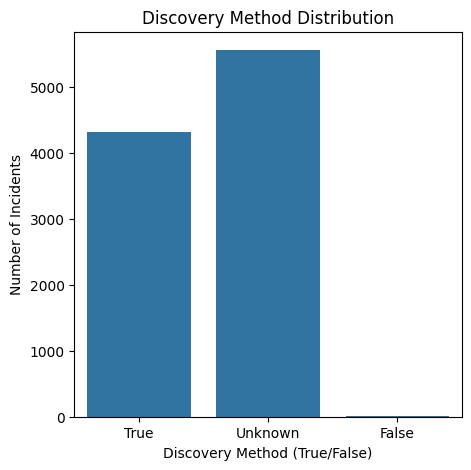

In [ ]:
# Plotting the distribution of discovery methods
plt.figure(figsize=(5, 5))
sns.countplot(x='discovery_method', data=df)
plt.title('Discovery Method Distribution')
plt.xlabel('Discovery Method (True/False)')
plt.ylabel('Number of Incidents')
plt.show()

<ipython-input-29-2e08e7258c94>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_count_filtered.index, y=country_count_filtered.values, palette="viridis")


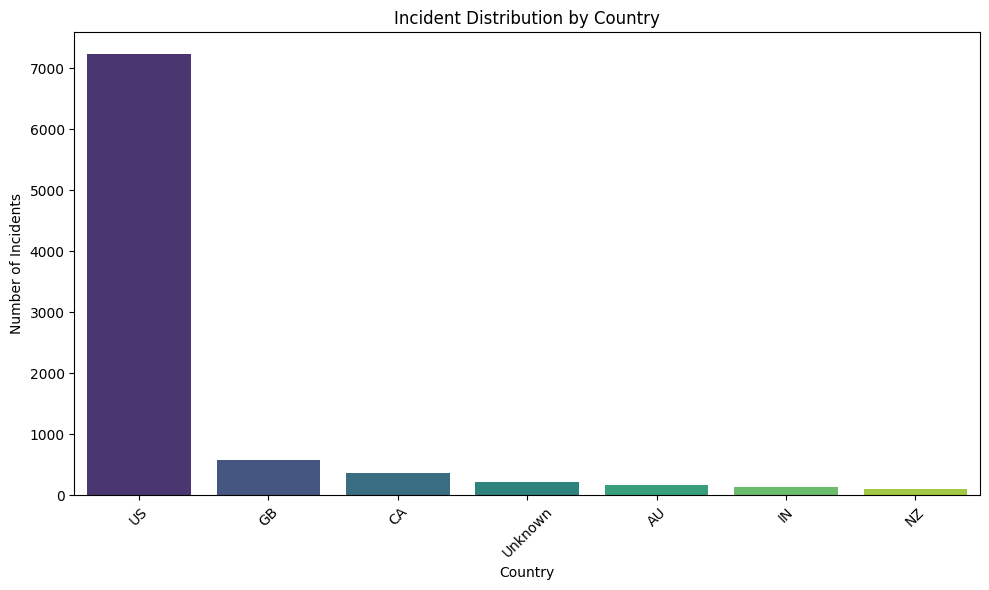

In [ ]:
# Clean up the country data
# Filter out countries with fewer than a threshold of incidents
country_threshold = 100

# Count the occurrences of each country
country_count = df['victim_country'].value_counts()

# Filter out countries with fewer than the threshold incidents
country_count_filtered = country_count[country_count >= country_threshold]

# Plot the filtered and sorted count of incidents by country
plt.figure(figsize=(10, 6))
sns.barplot(x=country_count_filtered.index, y=country_count_filtered.values, palette="viridis")
plt.title('Incident Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)  # Rotate country labels for better readability
plt.tight_layout()  # Adjust layout to fit labels better
plt.show()

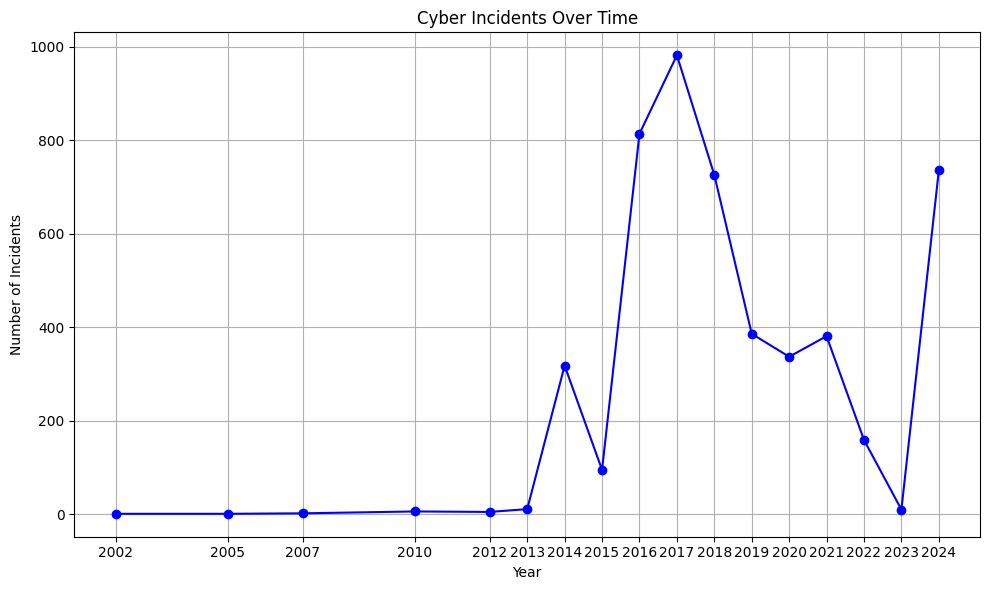

In [ ]:
# Line Graph: Cyber Incidents Over Time
# First, we ensure that 'dbir_year' is in the correct format (i.e., a numeric type)
df['dbir_year'] = pd.to_numeric(df['dbir_year'], errors='coerce')

# Group incidents by year and count occurrences
incident_by_year = df.groupby('dbir_year').size()

# Create a Line Graph
plt.figure(figsize=(10, 6))
incident_by_year.plot(kind='line', marker='o', linestyle='-', color='b')
plt.title('Cyber Incidents Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.grid(True)
plt.xticks(incident_by_year.index)  # Ensure all years are shown on the x-axis
plt.tight_layout()  # Adjust layout to prevent label clipping
plt.show()

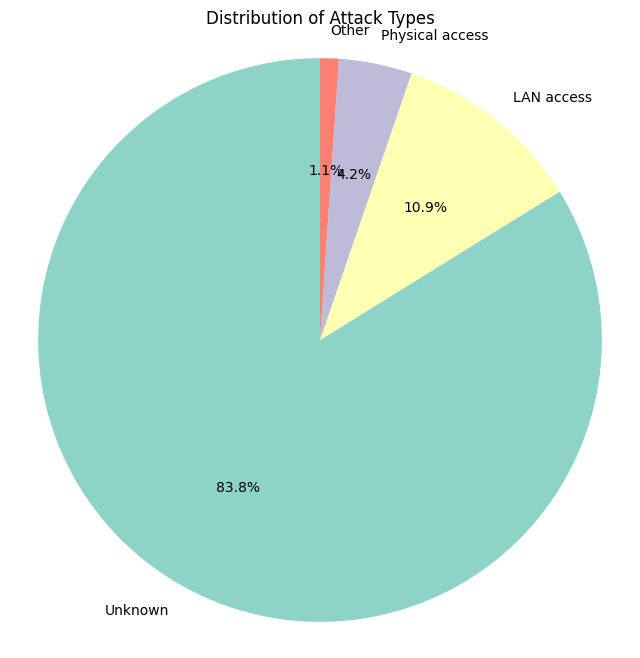

In [ ]:
# Pie Chart: Attack Types Distribution
# Count the occurrences of each attack type (including NaN values)
attack_counts = df['attack_vector'].value_counts(dropna=False)

# Set a threshold to only include attack types that occur more than a certain number of times
threshold = 100  # You can adjust this threshold based on your data
attack_counts_filtered = attack_counts[attack_counts >= threshold]

# Group remaining smaller categories into 'Other'
attack_counts_filtered['Other'] = attack_counts[attack_counts < threshold].sum()

# Plot the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(attack_counts_filtered, labels=attack_counts_filtered.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set3", len(attack_counts_filtered)))
plt.title('Distribution of Attack Types')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Project Summary: Cyberthreat Exposure Analysis

Objective
The project aims to analyze global cyberthreat exposure, focusing on:

Identifying demographics or industries most vulnerable to cyberthreats.
Understanding the means (attack types or vectors) by which breaches occur.
Highlighting countries or regions most affected by cyber incidents.

Dataset

Source: The VERIS Community Database (VCDB), based on the Verizon Data Breach Investigations Report (DBIR).
Contents: JSON records of real-world cyber incidents, including:
Victim industry, size, and breach year.
Attack vectors (e.g., phishing, malware, hacking).
Impact severity and affected assets.

Tools

Google Colab: For coding and analysis.
Python Libraries:
os and json for file handling.
pandas for data manipulation.
matplotlib for visualizations.
Steps
Data Acquisition:

Clone the VCDB dataset from GitHub.
Parse JSON files to extract relevant fields.

Data Preparation:

Extract and organize key fields:

Victim industry and size.
Year of the incident.
Attack types (e.g., hacking, malware).
Breach impact (e.g., financial losses, data disclosure).
Clean and filter incomplete or irrelevant records.
Analysis:

Industry Trends: Identify which industries are most targeted.
Attack Patterns: Determine the most common attack types (e.g., phishing, ransomware).
Geographic Insights: Analyze breaches by country (if location data is available).
Trends Over Time: Explore incident patterns across years.
Visualization:

Bar chart: Top 5 industries affected by breaches.
Pie chart: Most common attack vectors.
Line graph: Number of incidents per year.
Export Results:

Save a summary of the processed data (CSV).
Include visualizations for reporting or presentation.
Deliverables
Insights:

Top industries and demographics exposed to cyberthreats.
Common methods attackers use (e.g., phishing emails, stolen credentials).
Global patterns and trends over time.
Visualizations:

Bar Chart: Most affected industries.
Pie Chart: Attack types.
Line Graph: Cyber incidents over time.
Dataset:

A cleaned and structured CSV summarizing cyber incidents.
Simplified Workflow
Clone → Parse → Analyze → Visualize → Export.
Example Insights
Healthcare and financial industries might emerge as top targets.
Phishing is likely a leading attack vector.
Cyber incidents may trend upward over recent years.
Next Steps
Implement the provided Colab code to start exploring the dataset.
Adjust fields based on the dataset structure after inspecting a sample JSON file.
Interpret findings and refine analysis for impactful conclusions.